## Analytical Solution
#### Using Sisson 1987
##### Brooks-Corey and ROSETTA/van Genuchten Parameters

In [18]:
import numpy as np
import matplotlib.pyplot as plt

##### ROSETTA/vG style soil parameter table

In [19]:
soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    }       
}


##### Conversion of van Genuchten n to Brooks-Corey n

In [20]:
def vg_to_bc_n(vg_n):
    """
    Placeholder conversion from van Genuchten n to Brooks-Corey/Sisson n.
    This should be checked before final thesis use.
    """
    return 1 / (vg_n - 1)

##### Analytical Solution

In [ ]:
def theta_brooks_corey_sisson(z, t, theta_r, theta_s, Ks, bc_n):
    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    s = np.maximum(z / t, 1e-12)

    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / (1 / bc_n - 1)

    Se = (s / A) ** exponent
    theta_raw = theta_r + Se * (theta_s - theta_r)

    theta = np.clip(theta_raw, theta_r, theta_s)

    return theta_raw

In [ ]:
def theta_brooks_corey_sisson_piecewise(z, t, theta_r, theta_s, Ks, bc_n): ### piecewise to help with 
    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    s = np.maximum(z / t, 1e-12)

    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / (1 / bc_n - 1)

    Se = (s / A) ** exponent
    theta_mid = theta_r + Se * (theta_s - theta_r)

    theta = np.empty_like(z)

    # Piecewise regions
    theta[theta_mid <= theta_r] = theta_r
    theta[theta_mid >= theta_s] = theta_s

    middle = (theta_mid > theta_r) & (theta_mid < theta_s)
    theta[middle] = theta_mid[middle]

    """plt.plot(theta_mid, z)
    plt.gca().invert_yaxis()
    plt.xlabel("raw analytical theta")
    plt.ylabel("Depth [cm]")
    plt.show()"""

    return theta

#### Plot for one soil first

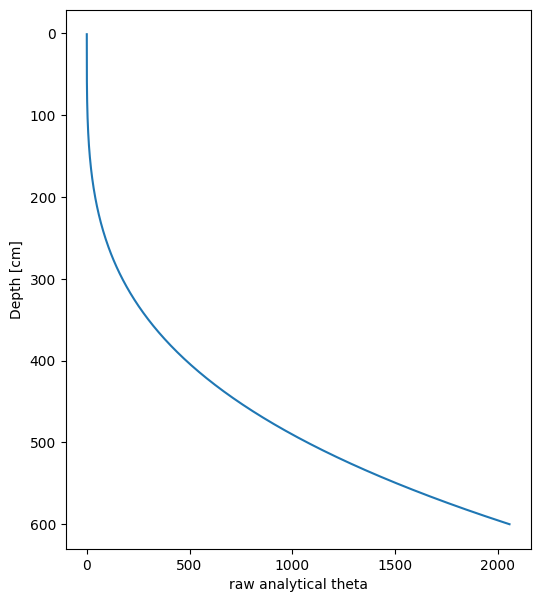

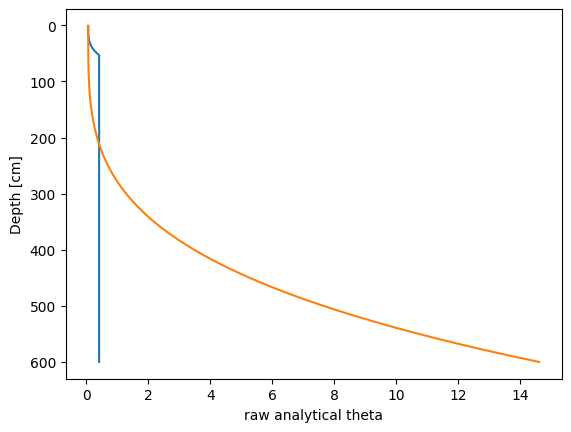

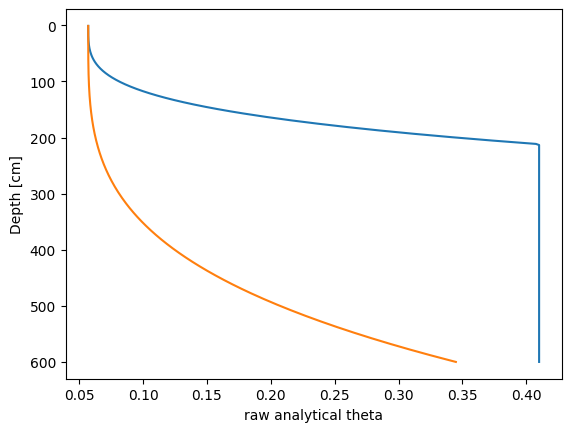

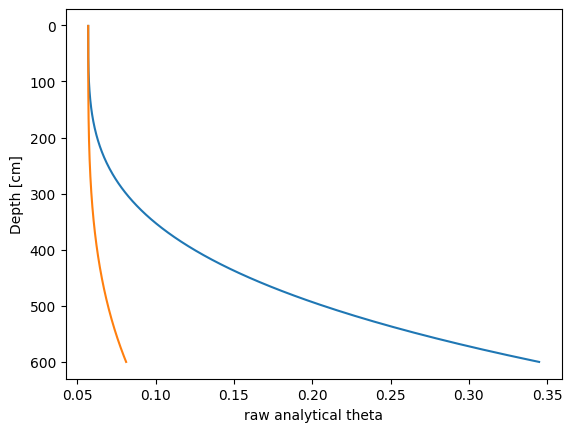

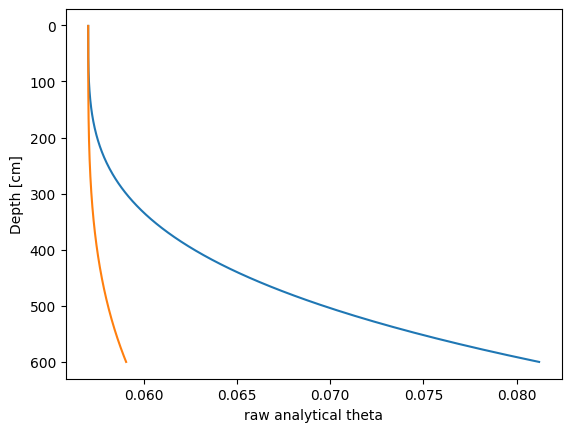

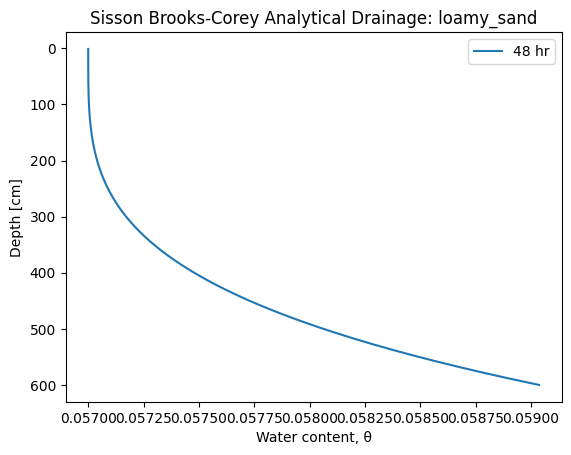

In [30]:
import matplotlib.pyplot as plt

z = np.linspace(1, 600, 300)  # cm, positive downward
times = [1, 4, 12, 24, 48]   # hr

soil_name = "loamy_sand"
soil = soils[soil_name]
bc_n = vg_to_bc_n(soil["vg_n"])

plt.figure(figsize=(6, 7))

for t in times:
    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=bc_n
    )
    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey Analytical Drainage: {soil_name}")
plt.legend()
plt.show()

#### Plot for all soils 

In [ ]:
for soil_name, soil in soils.items():
    bc_n = vg_to_bc_n(soil["vg_n"])

    plt.figure(figsize=(6, 7))

    for t in times:
        theta = theta_brooks_corey_sisson(
            z=z,
            t=t,
            theta_r=soil["theta_r"],
            theta_s=soil["theta_s"],
            Ks=soil["Ks"],
            bc_n=bc_n
        )
        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"{soil_name}: Analytical Drainage Profile")
    plt.legend()
    plt.show()